<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

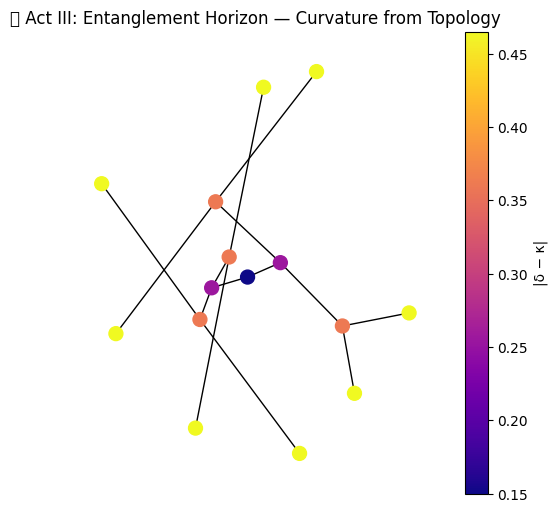

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

# -------------------------------
# Step 1: Build MERA-like Network
# -------------------------------
def build_entanglement_network(depth=4, branching=2):
    """
    Create a layered causal network with entanglement edges.
    """
    G = nx.DiGraph()
    node_id = 0
    layers = []

    for d in range(depth):
        layer = []
        for b in range(branching ** d):
            G.add_node(node_id, layer=d)
            layer.append(node_id)
            node_id += 1
        layers.append(layer)

    # Connect layers with entanglement edges
    for d in range(depth - 1):
        for parent in layers[d]:
            children = layers[d + 1]
            for c in range(branching):
                child = children[(parent * branching + c) % len(children)]
                G.add_edge(parent, child)

    return G

# -------------------------------
# Step 2: Assign δ and κ to Nodes
# -------------------------------
def assign_entropic_weights(G, delta=0.75, kappa=0.6):
    for node in G.nodes:
        layer = G.nodes[node]['layer']
        G.nodes[node]['delta'] = delta * (1 + 0.1 * layer)
        G.nodes[node]['kappa'] = kappa * (1 - 0.05 * layer)

# -------------------------------
# Step 3: Compute Curvature from Entropic Flow
# -------------------------------
def compute_curvature(G):
    curvature = {}
    for node in G.nodes:
        δ = G.nodes[node]['delta']
        κ = G.nodes[node]['kappa']
        curvature[node] = np.abs(δ - κ)
    return curvature

# -------------------------------
# Step 4: Visualize Network with Colorbar
# -------------------------------
def plot_entanglement_network(G, curvature):
    pos = nx.spring_layout(G, seed=42)
    node_colors = [curvature[n] for n in G.nodes]

    fig, ax = plt.subplots(figsize=(6, 6))
    nodes = nx.draw_networkx_nodes(G, pos, node_size=100, node_color=node_colors, cmap='plasma', ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=False, ax=ax)
    sm = ScalarMappable(cmap='plasma')
    sm.set_array(node_colors)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('|δ − κ|')
    ax.set_title("🧠 Act III: Entanglement Horizon — Curvature from Topology")
    plt.axis('off')
    plt.show()

# -------------------------------
# Step 5: Run Simulation
# -------------------------------
G = build_entanglement_network()
assign_entropic_weights(G)
curvature = compute_curvature(G)
plot_entanglement_network(G, curvature)
